In [11]:
import numpy as np

data = np.load("../../outputs/advection/2D/validation/advection_lax_w_upwind_gaussian_N(100, 100)_20260708_224030/data/spatial_data.npz")

print(data.files)

['x', 'u_numerical', 'u_analytical', 'ml_tensor_data']


In [13]:
x = data['x']
u_numerical = data['u_numerical']
u_analytical = data['u_analytical']
ml_tensor_data = data['ml_tensor_data']

for key in data.files:
    print(key, data[key].shape)


x (2, 100, 100)
u_numerical (100, 100)
u_analytical (100, 100)
ml_tensor_data (178, 100, 100)


In [18]:
input_data = ml_tensor_data[0]

uhat = np.fft.rfft(input_data)

print(input_data.shape)
print(uhat.shape)

(100, 100)
(100, 51)


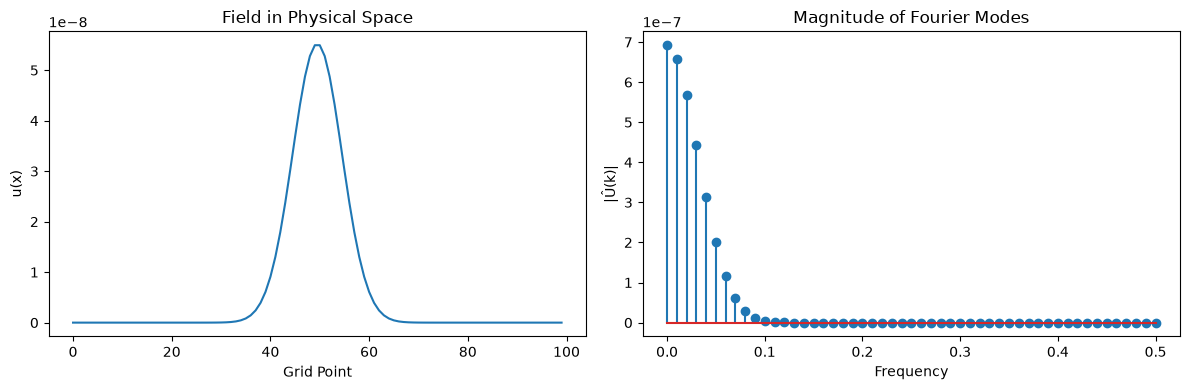

In [19]:
import numpy as np
import matplotlib.pyplot as plt

t = 20          # choose any timestep

field = input_data[t]
coeffs = np.fft.rfft(field)

freqs = np.fft.rfftfreq(len(field))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(field)
plt.title("Field in Physical Space")
plt.xlabel("Grid Point")
plt.ylabel("u(x)")

plt.subplot(1,2,2)
plt.stem(freqs, np.abs(coeffs))
plt.title("Magnitude of Fourier Modes")
plt.xlabel("Frequency")
plt.ylabel("|Û(k)|")

plt.tight_layout()
plt.show()

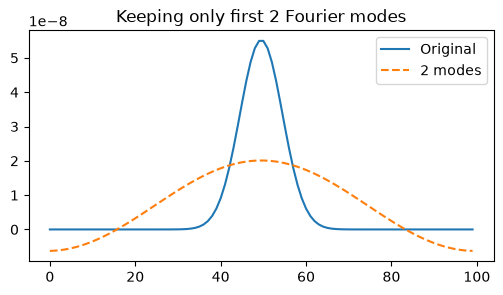

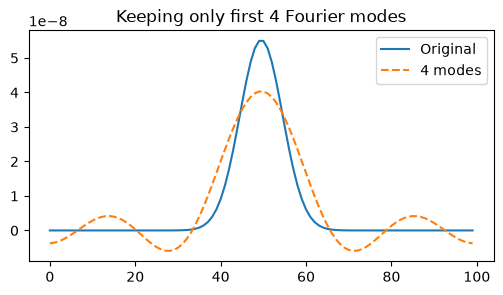

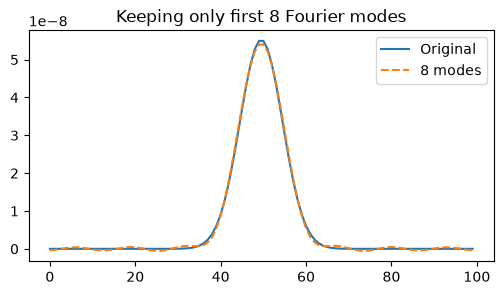

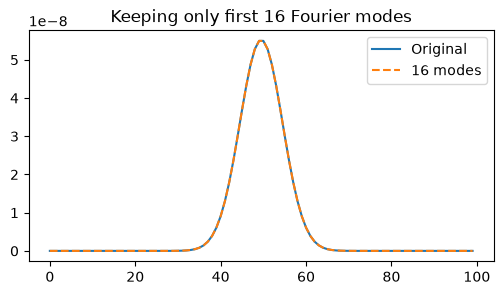

In [20]:
coeffs = np.fft.rfft(field)

for k in [2, 4, 8, 16]:
    filtered = coeffs.copy()
    filtered[k:] = 0

    reconstructed = np.fft.irfft(filtered)

    plt.figure(figsize=(6,3))
    plt.plot(field, label="Original")
    plt.plot(reconstructed, '--', label=f"{k} modes")
    plt.legend()
    plt.title(f"Keeping only first {k} Fourier modes")
    plt.show()